In [1]:
import sys
sys.path.append('../lib')
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt
import basicfunc as func
import analys_lib as an

In [2]:
nside = 64
lmax = 2*nside+1
Nlbin = 10
fsky = 0.7
scale = 10
nu0d = 402
nu0s = 40

instr_name ='litebird_full'
instr =  np.load('../lib/instr_dict/%s.npy' % instr_name, allow_pickle=True).item()
freq = instr['frequencies']
N_freqs = len(freq)
Ncross = int(N_freqs *(N_freqs+1) / 2)
Ngrid = 50

bw = instr['bandwidths']
freq_grids = np.zeros((N_freqs, Ngrid))
for i in range(N_freqs):
    freq_grids[i] = np.geomspace(freq[i]-bw[i]/2, freq[i]+bw[i]/2, Ngrid)
freq = freq_grids

b = nmt.NmtBin.from_nside_linear(nside, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
leff = leff[leff + (Nlbin+1)/2 <= lmax]
Nbins = len(leff)

mask = hp.read_map('../masks/mask_fsky%s_nside%s_aposcale%s.npy' % (fsky, nside, scale))

f = nmt.NmtField(mask, None, spin=2, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

Cl_lens_theory = np.zeros((4, 3*nside))
Cl_lens_theory[[0, 3]] = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')[[1,2], :3*nside]
Dl_lens = w.decouple_cell(w.couple_cell(Cl_lens_theory))[3, :Nbins]

In [3]:
data = np.load('/pscratch/sd/s/svinzl/B_modes_project/power_spectra/DLcross_nside64_fsky0.7_scale10_Nlbin10_dbsbc_gaussbeam_bandpass.npy')[:, :, :Nbins]
results = np.load('../best_fits/results_dbsb_0.7_scale10_Nmt-fg_gaussbeam_bandpass_ds_o1bts_analytical.npy', allow_pickle=True).item()

covmat = np.load('/pscratch/sd/s/svinzl/B_modes_project/covariances/cov_%s_nside%s_fsky%s_scale%s_Nlbin%s_d%ss%sc' % ('Nmt-fg', nside, fsky, scale, Nlbin, 'b', 'b')+'_gaussbeam_bandpass'+'.npy')[:Ncross*Nbins, :Ncross*Nbins]
comp = [['A', 'As', 'Asd', 'cmb']
        for i in range(Nbins)]

gauss = an.gauss_like(freq, leff, covmat, comp, results['beta_d'], results['T_d'], results['beta_s'], nu0d, nu0s, Dl_lens=None, Dl_tens=None)

In [4]:
temp_402 = np.mean(data[:, -1], axis=0) - np.mean(results['cmb'], axis=1)
temp_40 = np.mean(data[:, 0], axis=0) - np.mean(results['cmb'], axis=1)
temp_40_402 = np.mean(data[:, 21], axis=0) - np.mean(results['cmb'], axis=1)

for i in range(Nbins):
    temp_40[i] -= temp_402[i] * gauss.f_ij(i, 'A')[0]
    temp_40[i] -= temp_40_402[i] * gauss.f_ij(i, 'Asd')[0]
    """
    keys = list(results)[3:-5].copy()
    for k in keys:
        temp_40[i] -= np.mean(results[k][i]) * gauss.f_ij(i, k)[0]
    """

for i in range(Nbins):
    temp_40 /= gauss.f_ij(i, 'As')[0]
    temp_402 /= gauss.f_ij(i, 'A')[-1]
    temp_40_402 /= gauss.f_ij(i, 'Asd')[21]

              
A = np.mean(results['A'], axis=1)
As = np.mean(results['As'], axis=1)
Asd = np.mean(results['Asd'], axis=1)

In [11]:
Dl_402_402 = np.mean(data[:, -1], axis=0)
Dl_40_40 = np.mean(data[:, 0], axis=0)
Dl_40_402 = np.mean(data[:, 21], axis=0)
Dl_CMB = np.mean(results['cmb'], axis=1)

temp_40 = np.zeros(Nbins)
temp_40_402 = np.zeros(Nbins)
temp_402 = np.zeros(Nbins)

for i in range(Nbins):   
    eps_d = gauss.f_ij(i, 'A')
    eps_s = gauss.f_ij(i, 'As')
    eps_sd = gauss.f_ij(i, 'Asd')
    
    temp_40[i] = ((eps_s[0] - eps_s[-1] * eps_d[0] / eps_d[-1]
                 - (eps_s[21] - eps_s[-1] * eps_d[21] / eps_d[-1])
                 * (eps_sd[0] - eps_sd[-1] * eps_d[0] / eps_d[-1]) / (eps_sd[21] - eps_sd[-1] * eps_d[21] / eps_d[-1])
                  ) ** (-1)
                 
                  
                  * (Dl_40_40[i] - eps_d[0] / eps_d[-1] * Dl_402_402[i] - (1 - eps_d[0] / eps_d[-1]) * Dl_CMB[i]
                    - (eps_sd[0] - eps_sd[-1] * eps_d[0] / eps_d[-1]) / (eps_sd[21] - eps_sd[-1] * eps_d[21] / eps_d[-1])
                    * (Dl_40_402[i] - eps_d[21] / eps_d[-1] * Dl_402_402[i] - (1 - eps_d[21] / eps_d[-1]) * Dl_CMB[i])
                    )
                 )

    temp_40_402[i] = ((eps_sd[21] - eps_sd[-1] * eps_d[21] / eps_d[-1]) ** (-1)
                      * (Dl_40_402[i] - eps_d[21] / eps_d[-1] * Dl_402_402[i] - (1 - eps_d[21] / eps_d[-1]) * Dl_CMB[i]
                      - temp_40[i] * (eps_s[21] - eps_s[-1] * eps_d[21] / eps_d[-1])
                        )
                     )

    temp_402[i] = (Dl_402_402[i] - Dl_CMB[i] - temp_40[i] * eps_s[-1] - temp_40_402[i] * eps_sd[-1]) / eps_d[-1]

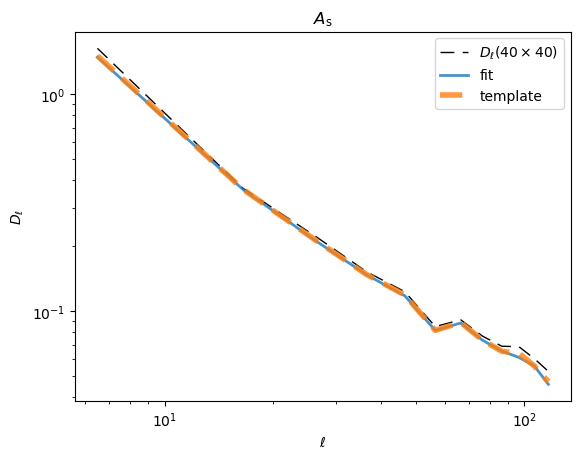

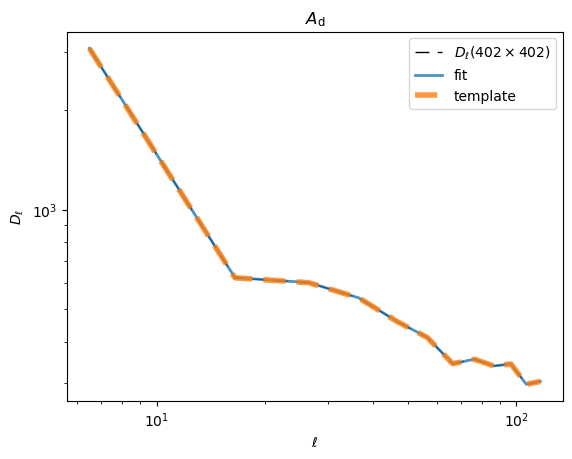

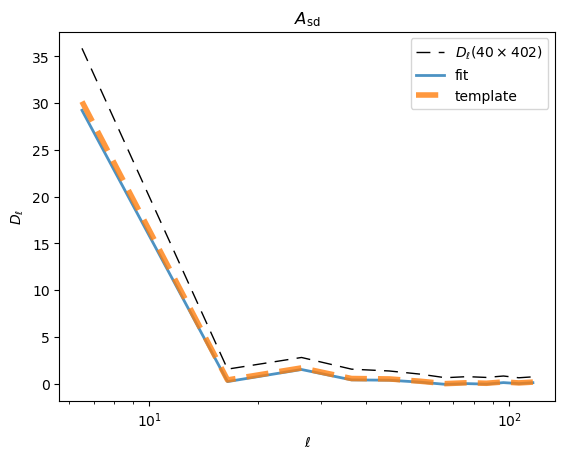

In [12]:
plt.figure(figsize=(6.4, 4.8))
plt.plot(leff, Dl_40_40, linestyle=(0, (10,6)), linewidth=1, color='black', label=r'$D_\ell(40 \times 40)$')
plt.plot(leff, As, linewidth=2, label='fit', alpha=0.8)
plt.plot(leff, temp_40, linestyle=(0, (4,2)), linewidth=4, label='template', alpha=0.8)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell$')
plt.title(r'$A_{\rm s}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(6.4, 4.8))
plt.plot(leff, Dl_402_402, linestyle=(0, (10,6)), linewidth=1, color='black', label=r'$D_\ell(402 \times 402)$')
plt.plot(leff, A, linewidth=2, label='fit', alpha=0.8)
plt.plot(leff, temp_402, linestyle=(0, (4,2)), linewidth=4, label='template', alpha=0.8)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell$')
plt.title(r'$A_{\rm d}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

plt.figure(figsize=(6.4, 4.8))
plt.plot(leff, Dl_40_402, linestyle=(0, (10,6)), linewidth=1, color='black', label=r'$D_\ell(40 \times 402)$')
plt.plot(leff, Asd, linewidth=2, label='fit', alpha=0.8)
plt.plot(leff, temp_40_402, linestyle=(0, (4,2)), linewidth=4, label='template', alpha=0.8)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell$')
plt.title(r'$A_{\rm sd}$')
plt.xscale('log')
plt.legend()
plt.show()